# Paper-Moon 🌙
### The Fed Model: a famous timing rule built on a logical bug

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![The model's logic holds?: Busted](https://img.shields.io/badge/The_model's_logic_holds%3F-Busted-8b949e?style=flat-square)

"Stocks are cheap when their earnings yield beats the 10-year Treasury yield." It sounds obvious, it has a Fed-sounding name, and it's quoted constantly. Over 125 years it times the market no better than buying and holding — and its key idea, comparing stocks to bonds, turns out to add *nothing detectable*. It's only a paper moon.

> 📓 **Plain-language layer.** The forecasting horse-race and the inflation illusion are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (paper_moon/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from paper_moon import data, strategy as st
d = data.fetch_shiller(start_year=1900)        # cache-first; built by examples/verify.py --fetch
sig = st.fed_signal(d["ep"], d["y10"])
timing = st.fed_timing(d["tr"], d["bond"], sig); bh = st.buy_hold(d["tr"]).reindex(timing.index)


## The answer first 🎯

| The pitch | The catch |
|---|---|
| "Time the market with E/P vs bond yields" | It matches buy-and-hold's Sharpe and **loses** a point of return. |
| "The bond comparison is the insight" | **E/P alone forecasts at least as well** — the gap is inside overlap-corrected noise. |
| "A sound valuation model" | It confuses a *real* earnings yield with a *nominal* bond yield. |

## 1 · The claim

The Fed Model: hold equities when the S&P earnings yield (E/P) is above the 10-year Treasury yield (stocks 'cheap' relative to bonds), and step into bonds when it's below. A market-timing rule taught in every CFA prep book.

## 2 · So what?

If comparing equity and bond yields times the market, it's a simple, powerful asset-allocation switch. If the comparison is a conceptual error, then a generation of strategists has been anchoring on a number that means less than it seems.

## 3 · How would we even know?

Run the timing on 125 years of Shiller data against buy-and-hold; then the decisive test — does the **Fed signal (E/P − yield)** forecast future returns better than **E/P alone**? If not, the bond term is dead weight. One honesty rule: 12-month forward returns overlap massively, so ~1,500 monthly rows are really ~125 independent observations — the error bars below come from a block bootstrap that respects that.

,cagr,sharpe,max_drawdown
Fed-model timing,9.0%,0.72,-81%
Buy & hold S&P,10.0%,0.73,-81%


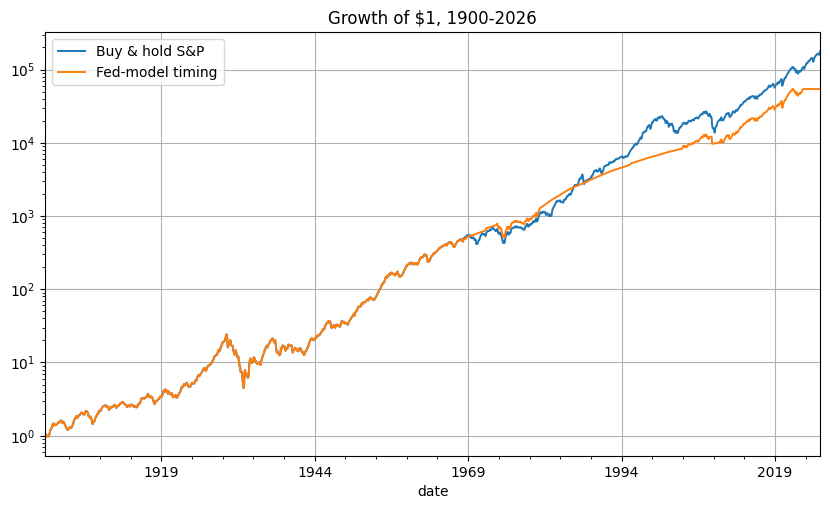

In [2]:
rows={'Fed-model timing':st.summary(timing),'Buy & hold S&P':st.summary(bh)}
t=pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown']]
display(t.style.format({'cagr':'{:.1%}','sharpe':'{:.2f}','max_drawdown':'{:.0%}'}))
eqT=(1+timing).cumprod(); eqB=(1+bh).cumprod()
ax=eqB.plot(label='Buy & hold S&P',lw=1.4); eqT.plot(ax=ax,label='Fed-model timing',lw=1.4)
ax.set_yscale('log'); ax.set_title('Growth of $1, 1900-2026'); ax.legend(); plt.show()

## 4 · The teardown — does the bond comparison help?

This is the whole study in one chart: the Fed signal vs E/P alone as forecasters of the next year's return.

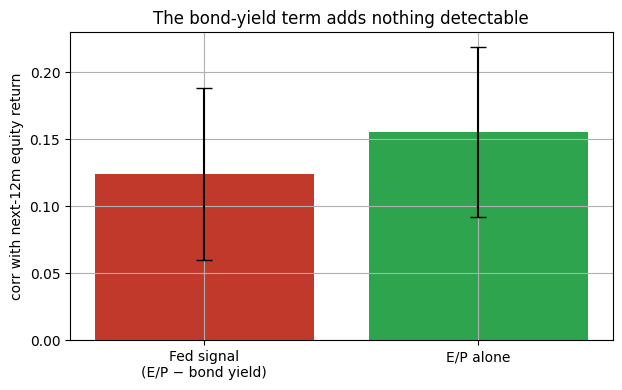

Fed signal +0.12 ± 0.06   vs   E/P alone +0.16 ± 0.06
difference (E/P − Fed) +0.03 ± 0.05, 95% CI [-0.07, +0.13]
(1505 overlapping monthly obs ≈ 125 independent ones)


In [3]:
race=st.predictive_corr_race(d['ep'],sig,d['tr'])  # overlap-corrected block-bootstrap SEs
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['Fed signal\n(E/P − bond yield)','E/P alone'],[race['corr2'],race['corr1']],
       yerr=[race['se2'],race['se1']],capsize=6,color=['#c0392b','#2ea44f'])
ax.set_ylabel('corr with next-12m equity return'); ax.set_title('The bond-yield term adds nothing detectable'); plt.show()
print(f"Fed signal {race['corr2']:+.2f} ± {race['se2']:.2f}   vs   E/P alone {race['corr1']:+.2f} ± {race['se1']:.2f}")
print(f"difference (E/P − Fed) {race['diff']:+.2f} ± {race['se_diff']:.2f}, 95% CI [{race['diff_lo']:+.2f}, {race['diff_hi']:+.2f}]")
print(f"({race['n']} overlapping monthly obs ≈ {race['n_indep']} independent ones)")

**Read it plainly.** E/P by itself forecasts at least as well as the famous comparison — and once the error bars respect the overlap (~125 independent year-length observations, not 1,505 monthly rows), the gap (+0.03 ± 0.05) is pure noise. Subtracting the bond yield adds nothing detectable: the model's signature ingredient is decoration.

## 5 · The verdict

**Signal: Weak** — only plain valuation (E/P) carries anything. **Tradability: Mirage** — buy-and-hold with worse return. **Logic holds?: Busted** — the bond comparison is inert and rests on a money illusion.

## 6 · Could you actually trade it?

You could, but you'd underperform buy-and-hold over a century while taking on switching risk. If you want the valuation signal, use E/P (or CAPE) directly — and skip the bond-yield comparison that gives the model its name and its flaw.

## 7 · Going further 🚪

The quants notebook shows *why* the comparison fails — E/P tracks inflation, not the bond yield (Asness 2003, *Fight the Fed Model*). Next: [Study 48 Groundhog](../../48-groundhog/) — return seasonality, a genuinely strange claim about stocks repeating their calendar-month performance.